In [15]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import soundfile as sf
import torchvision.models as models
from IPython.display import clear_output
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, Dataset
import wandb
import librosa 

%matplotlib inline

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "."))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes = ["Electronic", "Experimental", "Folk", "Hip-Hop", "Instrumental", "International", "Pop", "Rock"]

wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

In [16]:
class AudioDataset(Dataset):
    def __init__(
        self,
        path_to_csv: str,
        path_to_folder: str,
        pad_size: int,
        sr: int = 44100,
    ):
        self.csv = pd.read_csv(path_to_csv)[["track_id", "genre"]]
        self.path_to_folder = path_to_folder
        self.pad_size = pad_size
        self.sr = sr
        self.class_to_idx = {classes[i]: i for i in range(len(classes))}

    def __getitem__(self, index: int):
        row = self.csv.iloc[index]

        file_id = str(row["track_id"])
        if not file_id.endswith(".wav"):
            file_id += ".wav"

        path = os.path.join(self.path_to_folder, file_id)

        x, sr = sf.read(path)
        x = torch.tensor(x, dtype=torch.float32)
        
        if x.ndim == 2:
            x = x.mean(dim=1)
            
        if sr != self.sr:
            x = torchaudio.functional.resample(x, sr, self.sr)

        real_len = x.shape[0]

        if real_len < self.pad_size:
            pad_len = self.pad_size - real_len
            x = torch.nn.functional.pad(x, (0, pad_len))
        else:
            x = x[:self.pad_size]
            real_len = self.pad_size

        y = int(row["genre"])

        return {"x": x, "y": y, "len": real_len}

    def __len__(self):
        return self.csv.shape[0]

In [17]:
duration = 3
padsize = int(44100 * duration)

train_dataset = AudioDataset(
    os.path.join(BASE_DIR, "data_csv", "train_meta_nopop.csv"),
    os.path.join(BASE_DIR, "data", "audio_train"), pad_size=padsize
)
val_dataset = AudioDataset(
    os.path.join(BASE_DIR, "data_csv", "val_meta_nopop.csv"),
    os.path.join(BASE_DIR, "data", "audio_val"), pad_size=padsize
)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

In [18]:
def compute_log_melspectrogram_resnet(wav_batch, lens, sr, device="cpu"):
    n_fft = 1024
    win_length = 1024
    hop_length = 256
    n_mels = 64

    wav_batch = wav_batch.to(device)

    windows = wav_batch.unfold(dimension=1, size=win_length, step=hop_length)
    filter = torch.hann_window(win_length, device=device)
    windows_with_applied_filter = windows * filter[None, None, :]

    fft_features = torch.fft.fft(windows_with_applied_filter, n=n_fft, dim=-1)[:, :, : n_fft // 2 + 1]
    fft_magnitudes = torch.abs(fft_features ** 2)

    melscale = torchaudio.transforms.MelScale(n_mels=n_mels, sample_rate=sr, n_stft=n_fft // 2 + 1).to(device)
    mel_spectrogram = melscale(fft_magnitudes.transpose(1, 2))
    logmel_spectrogram = torch.log(mel_spectrogram.clamp(1e-5)) 

    logmel_spectrogram = logmel_spectrogram.unsqueeze(1)
    
    logmel_spectrogram = F.interpolate(
        logmel_spectrogram, 
        size=(224, 224), 
        mode='bilinear', 
        align_corners=False
    )
    
    logmel_spectrogram = logmel_spectrogram.repeat(1, 3, 1, 1)

    return logmel_spectrogram, lens // hop_length



In [19]:
def build_resnet_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model

In [20]:
def train_audio_clfr(
    model,
    optimizer,
    train_dataloader,
    val_dataloader,
    sr,
    criterion=torch.nn.CrossEntropyLoss(),
    data_transform=None,
    num_epochs=10,
    device="cuda",
    verbose_num_iters=10,
):
    model.train()
    iter_i = 0

    train_losses = []
    train_accuracies = []

    for epoch in range(num_epochs):
        epoch_losses = []
        epoch_accs = []

        for batch in train_dataloader:
            x = batch["x"].to(device)
            y = batch["y"].to(device)
            lens = batch["len"].to(device)

            if data_transform:
                x, lens = data_transform(x, lens, device=device, sr=sr)

            probs = model(x) 
            optimizer.zero_grad()
            loss = criterion(probs, y)
            loss.backward()
            optimizer.step()

            loss_val = loss.item()
            train_losses.append(loss_val)
            epoch_losses.append(loss_val)

            pred_cls = probs.argmax(dim=-1)
            acc_val = (pred_cls == y).float().mean().item()
            train_accuracies.append(acc_val)
            epoch_accs.append(acc_val)

            wandb.log({"train/loss": loss_val, "train/accuracy": acc_val}, step=iter_i)

            iter_i += 1

            if iter_i % verbose_num_iters == 0:
                clear_output(wait=True)
                print(f"Epoch {epoch} | Iteration {iter_i}")

                plt.figure(figsize=(10, 5))
                plt.subplot(1, 2, 1)
                plt.xlabel("Iteration")
                plt.ylabel("Train loss")
                plt.plot(np.arange(iter_i), train_losses)

                plt.subplot(1, 2, 2)
                plt.xlabel("Iteration")
                plt.ylabel("Train acc")
                plt.plot(np.arange(iter_i), train_accuracies)
                plt.show()

        wandb.log({
            "epoch": epoch,
            "epoch/train_loss": np.mean(epoch_losses),
            "epoch/train_accuracy": np.mean(epoch_accs),
        }, step=iter_i)

    model.eval()
    return model

In [ ]:
def plot_confusion_matrix(model, val_dataloader, sr, device, data_transform=None):
    pred_true_pairs = []
    for batch in val_dataloader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)
        lens = batch["len"].to(device)

        with torch.no_grad():
            if data_transform:
                x, lens = data_transform(x, lens, sr=sr, device=device)

            probs = model(x, lens)

            pred_cls = probs.argmax(dim=-1)

        for pred, true in zip(pred_cls.cpu().detach().numpy(), y.cpu().numpy()):
            pred_true_pairs.append((pred, true))

    val_acc = np.mean([p[0] == p[1] for p in pred_true_pairs])
    print(f"Val accuracy: {val_acc}")

    wandb.log({"val/accuracy": val_acc})

    cm_df = pd.DataFrame(
        confusion_matrix(
            [p[1] for p in pred_true_pairs],
            [p[0] for p in pred_true_pairs],
            normalize="true",
        ),
        columns=classes,
        index=classes,
    )
    sn.heatmap(cm_df, annot=True)
    wandb.log({"confusion_matrix": wandb.Image(plt.gcf())})
    plt.show()

In [22]:
wandb.init(project="gp5-audio-classification", name="resnet18")

model = build_resnet_model(num_classes=len(classes)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 2 | Iteration 400


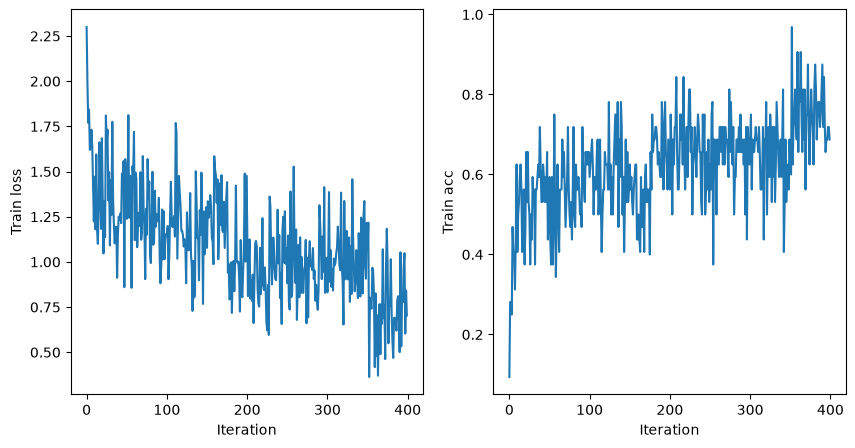

KeyboardInterrupt: 

In [24]:
trained_model = train_audio_clfr(
    model=model,
    optimizer=optimizer,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    sr=train_dataset.sr,
    data_transform=compute_log_melspectrogram_resnet,
    num_epochs=10,
    device=device,
    verbose_num_iters=50
)

In [25]:
model_path = "resnet18_fma_best.pth"
torch.save(trained_model.state_dict(), model_path)

model_artifact = wandb.Artifact("resnet18_model", type="model")
model_artifact.add_file(model_path)
wandb.log_artifact(model_artifact)

plot_confusion_matrix(
    model=trained_model,
    val_dataloader=val_dataloader,
    sr=train_dataset.sr,
    device=device,
    data_transform=compute_log_melspectrogram_resnet
)

wandb.finish()

NameError: name 'trained_model' is not defined

In [ ]:
from sklearn.metrics import accuracy_score

def evaluate_accuracy(model, val_dataloader, sr, device, data_transform=None):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch in val_dataloader:
            x = batch["x"].to(device)
            y = batch["y"].numpy()
            lens = batch["len"].to(device)
            
            if data_transform:
                x, lens = data_transform(x, lens, device=device, sr=sr)
                
            probs = model(x)
            preds = probs.argmax(dim=-1).cpu().numpy()
            
            all_preds.extend(preds)
            all_targets.extend(y)
            
    acc = accuracy_score(all_targets, all_preds)
    print(acc)
    return acc

val_accuracy = evaluate_accuracy(
    model=trained_model,
    val_dataloader=val_dataloader,
    sr=train_dataset.sr,
    device=device,
    data_transform=compute_log_melspectrogram_resnet
)


Validation Accuracy: 0.6128 (61.28%)


In [28]:
def build_resnet34_model(num_classes):

    model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)


    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model


wandb.init(project="gp5-audio-classification", name="resnet34_baseline")


resnet34_model = build_resnet34_model(num_classes=len(classes)).to(device)
optimizer = torch.optim.AdamW(resnet34_model.parameters(), lr=3e-4)


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\tim7m/.cache\torch\hub\checkpoints\resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [01:15<00:00, 1.15MB/s]


Epoch 9 | Iteration 1670


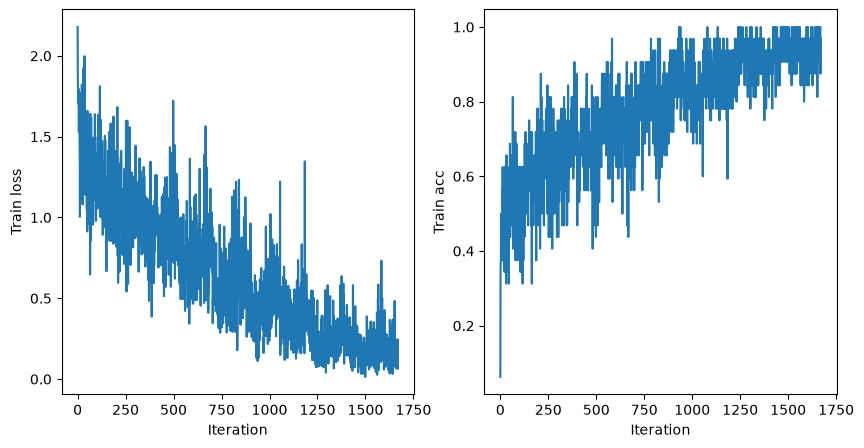

In [ ]:
resnet34_model = train_audio_clfr(
    model=resnet34_model,
    optimizer=optimizer,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    sr=44100,
    data_transform=compute_log_melspectrogram_resnet,
    num_epochs=10,
    device=device,
    verbose_num_iters=10
)


In [ ]:
model_path = "resnet34_fma_best.pth"
torch.save(trained_model.state_dict(), model_path)

model_artifact = wandb.Artifact("resnet34_model", type="model")
model_artifact.add_file(model_path)
wandb.log_artifact(model_artifact)

plot_confusion_matrix(
    model=trained_model,
    val_dataloader=val_dataloader,
    sr=train_dataset.sr,
    device=device,
    data_transform=compute_log_melspectrogram_resnet
)

wandb.finish()

In [ ]:
val_accuracy = evaluate_accuracy(
    model=trained_model,
    val_dataloader=val_dataloader,
    sr=train_dataset.sr,
    device=device,
    data_transform=compute_log_melspectrogram_resnet
)